# 08 — Đánh giá mô hình và thí nghiệm selection bias

**Công việc 2.4 (TV2)** — kế hoạch mục 3.5, thuyết minh TV2.

Nội dung:

1. `evaluate()` với 4 sơ đồ đánh giá (mục 3.5.1): `original_split`, `loocv`, `nested_cv`, `wrong_cv`
2. Chỉ số: balanced accuracy (chính), AUC, sensitivity/specificity (AML là lớp dương), Wilson CI
3. Kiểm định McNemar: mô hình tạm vs. baseline lớp đa số trên tập test 34 mẫu
4. Thí nghiệm selection bias 2×2 (giả thuyết H3): nhãn thật/hoán vị × CV đúng/sai → hình **F10**
5. ROC + ma trận nhầm lẫn của mô hình → hình **F11**

> Bản 1 dùng pipeline tạm (threshold+log10 → StandardScaler → SelectKBest k=50 → LogisticRegression)
> thay cho tầng curated/model của TV3; khi nhóm chốt mô hình cuối thì chạy lại cell tương ứng.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

# Chạy từ notebook/ nên phải đưa gốc repo (chứa src/, config/, results/) vào sys.path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# Sau threshold [100, 16000] nhiều gen thành hằng số nên f_classif cảnh báo hàng nghìn lần
# (điểm số không đổi, SelectKBest xếp NaN xuống cuối - xem evaluate.main). Tắt để đọc được.
warnings.filterwarnings("ignore", message=r"Features [\s\S]* are constant", category=UserWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in divide", category=RuntimeWarning)

from src.config import METRICS_DIR
from src.evaluate import (
    SCHEMES,
    _baseline_pipeline,
    evaluate,
    mcnemar_test,
    plot_roc_cm,
    plot_selection_bias,
    selection_bias_experiment,
    summarize_selection_bias,
)
from src.load import load_golub

pd.set_option("display.max_columns", 20)

In [2]:
X, samples = load_golub(layer="cleansed")
y = samples["class"]
pipe = _baseline_pipeline()   # pipeline tạm: log10 -> scale -> 50 gen -> logistic
print("X:", X.shape, "| samples:", samples.shape)
samples.head()

X: (72, 7129) | samples: (72, 7)


,split,class,subtype,tissue,source,sex,qc_outlier
sample_id,,,,,,,
1,train,ALL,B-ALL,BM,DFCI,M,False
2,train,ALL,T-ALL,BM,DFCI,M,False
3,train,ALL,T-ALL,BM,DFCI,M,False
4,train,ALL,B-ALL,BM,DFCI,None,False
5,train,ALL,B-ALL,BM,DFCI,None,False


## 1. Bốn sơ đồ đánh giá (mục 3.5.1)

Mọi bước học từ dữ liệu (chuẩn hóa, chọn gen) nằm **trong** pipeline nên được fit lại ở từng fold —
đây là điều kiện cần để các con số trung thực. `wrong_cv` cố ý chọn gen trên toàn bộ dữ liệu
trước khi CV, chỉ dùng để minh họa selection bias.

In [3]:
results = {}
for scheme in SCHEMES:
    results[scheme] = evaluate(pipe, X, y, scheme, split=samples["split"])

table = pd.DataFrame([
    {"scheme": s,
     "bal_acc_mean": r["bal_acc_mean"],
     "bal_acc_sd": r["bal_acc_sd"],
     "auc_mean": r["auc_mean"],
     "sens": r["per_fold"]["sensitivity"].mean(),
     "spec": r["per_fold"]["specificity"].mean(),
     "n_dong_per_fold": len(r["per_fold"])}
    for s, r in results.items()
])
table

,scheme,bal_acc_mean,bal_acc_sd,auc_mean,sens,spec,n_dong_per_fold
0,original_split,0.964286,NaN,0.992857,0.928571,1.000000,1
1,loocv,0.954545,NaN,1.000000,0.909091,1.000000,1
2,nested_cv,0.959556,0.04904,0.996978,0.956000,0.963111,50
3,wrong_cv,0.964000,0.04264,0.997867,0.960000,0.968000,50


In [4]:
# Kế hoạch yêu cầu evaluate() trả về đúng các khoá (demo nghiệm thu mục 5.3)
demo = evaluate(pipe, X, y, scheme="nested_cv", seeds=range(10))
list(demo.keys())

['bal_acc_mean', 'bal_acc_sd', 'auc_mean', 'per_fold', 'config', 'predictions']

## 2. Tập test 34 mẫu: Wilson CI và kiểm định McNemar

Wilson CI dùng cho accuracy vì n = 34 nhỏ; McNemar bản chính xác chỉ đếm các mẫu mà hai mô hình
dự đoán khác nhau. Đối chứng (nguyên tắc control): mô hình luôn đoán lớp đa số.

In [5]:
test = results["original_split"]
row = test["per_fold"].iloc[0]
print(f"accuracy = {row['accuracy']:.3f} | Wilson 95% CI = [{row['acc_ci_low']:.3f}, {row['acc_ci_high']:.3f}]")
print(f"sensitivity = {row['sensitivity']:.3f} | specificity = {row['specificity']:.3f} | AUC = {row['auc']:.3f}")

majority = evaluate(Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
                    X, y, "original_split", split=samples["split"])
mc = mcnemar_test(test["predictions"]["y_true"], test["predictions"]["y_pred"],
                  majority["predictions"]["y_pred"])
print(f"McNemar (mô hình tạm vs lớp đa số): đúng {mc['a_correct']} vs {mc['b_correct']}/{mc['n']}, "
      f"p = {mc['p_value']:.3g}")

accuracy = 0.971 | Wilson 95% CI = [0.851, 0.995]
sensitivity = 0.929 | specificity = 1.000 | AUC = 0.993
McNemar (mô hình tạm vs lớp đa số): đúng 33 vs 20/34, p = 0.000244


## 3. Thí nghiệm selection bias (giả thuyết H3)

Bảng 2×2: **nhãn thật / nhãn hoán vị (100 lần)** × **CV đúng / CV sai**.

- Nhãn thật → cả hai cách đều cao (mối liên hệ gen–nhãn là thật).
- Nhãn hoán vị → CV đúng phải quanh **0.50** (không còn tín hiệu), còn CV sai vẫn cao bất thường
  vì bước chọn gen nhìn thấy cả dữ liệu kiểm tra → bằng chứng H3.

Kết quả đã lưu tại `results/metrics/selection_bias_runs.csv` (do `make evaluate` sinh);
nếu file chưa có thì chạy lại thí nghiệm ngay tại đây.

In [6]:
runs_path = METRICS_DIR / "selection_bias_runs.csv"
if runs_path.exists():
    runs = pd.read_csv(runs_path)
    print(f"Đọc {len(runs)} lần chạy từ {runs_path.relative_to(ROOT)}")
else:
    runs = selection_bias_experiment(pipe, X, y, n_permutations=100)
    print(f"Chạy mới {len(runs)} lần chạy")

summary = summarize_selection_bias(runs)
summary["labels"] = summary["labels"].map({"real": "Thật", "permuted": "Hoán vị"})
summary["cv"] = summary["cv"].map({"correct": "Đúng", "wrong": "Sai"})
summary = summary.rename(columns={"labels": "Nhãn", "cv": "Cách CV",
                                  "bal_acc_mean": "Balanced accuracy (TB)",
                                  "bal_acc_sd": "SD", "n_runs": "Số lần"})
summary

Đọc 220 lần chạy từ results/metrics/selection_bias_runs.csv


,Nhãn,Cách CV,Balanced accuracy (TB),SD,Số lần
0,Thật,Đúng,0.959556,0.014375,10
1,Thật,Sai,0.964000,0.005646,10
2,Hoán vị,Đúng,0.500811,0.064978,100
3,Hoán vị,Sai,0.807000,0.058787,100


### Hình F10 — phân phối balanced accuracy của 4 tổ hợp

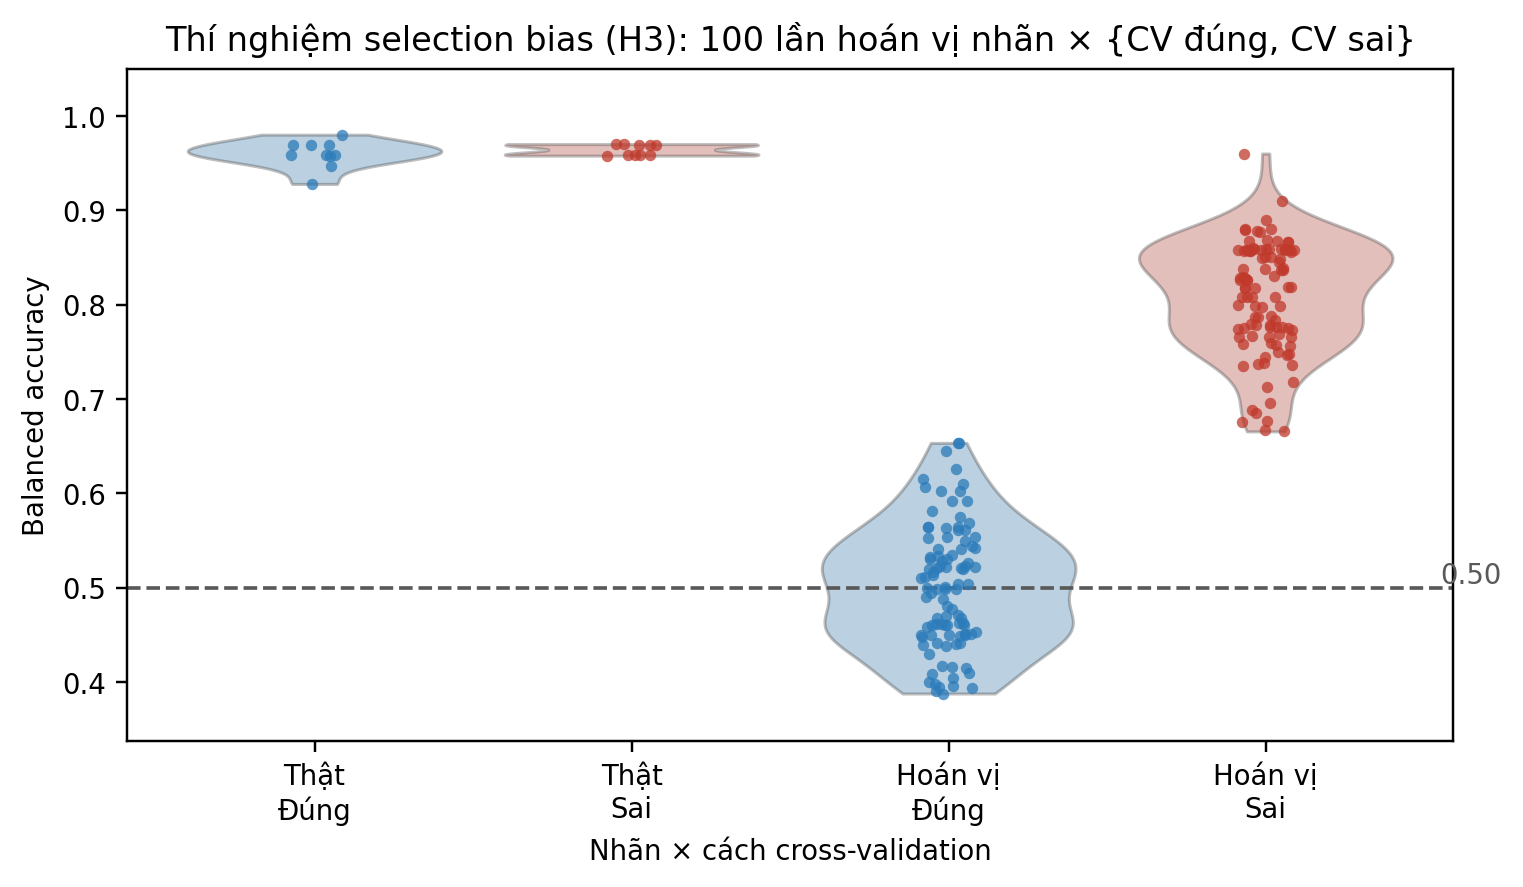

In [7]:
fig10 = plot_selection_bias(runs)
display(Image(filename=str(fig10[0])))   # bản report; bản slide ở results/figures/slides/

## 4. ROC và ma trận nhầm lẫn (hình F11)

Bản 1 vẽ cho pipeline tạm trên tập test 34 mẫu (`original_split`). Khi TV3 giao mô hình cuối
(công việc 2.3), chỉ cần gọi lại `plot_roc_cm` với dự đoán của mô hình đó.

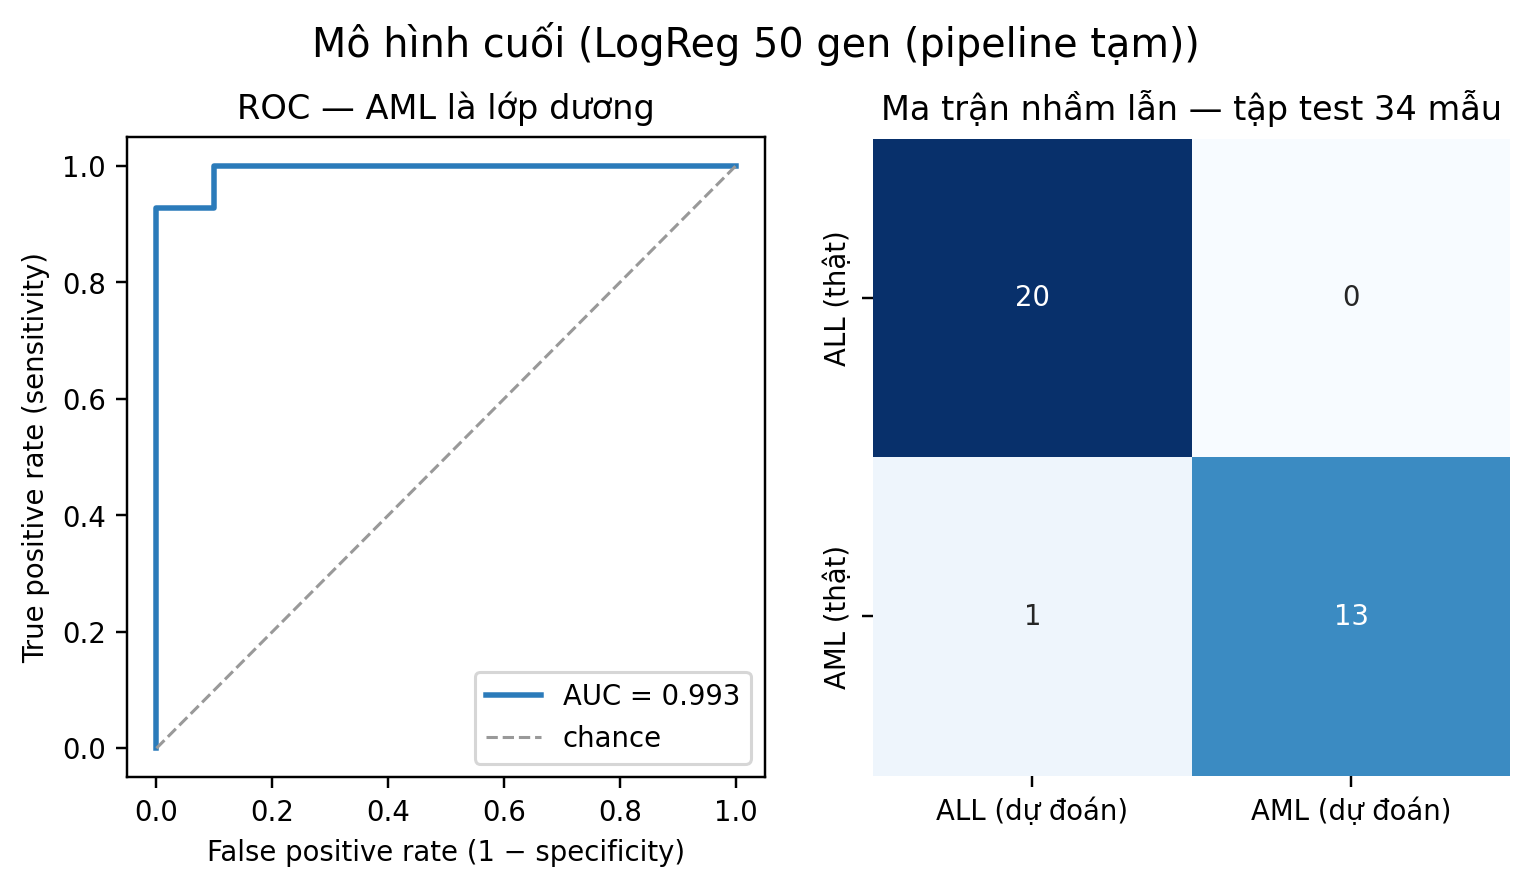

In [8]:
p = test["predictions"]
fig11 = plot_roc_cm(p["y_true"], p["y_pred"], p["score"],
                    model_name="LogReg 50 gen (pipeline tạm)")
display(Image(filename=str(fig11[0])))

## 5. Kết luận (viết vào mục 3.5 của báo cáo)

- Bốn sơ đồ cho kết quả nhất quán với pipeline tạm: `original_split` ≈ 0.96 balanced accuracy trên 34 mẫu test.
- **H3 được xác nhận bằng thực nghiệm**: với nhãn hoán vị, CV đúng quanh 0.50 còn CV sai cao hơn hẳn —
  chọn gen trước khi CV làm thổi phồng hiệu năng.
- Chống rò rỉ: mọi bước học nằm trong `Pipeline` và chỉ fit trên fold huấn luyện;
  `wrong_cv` tồn tại *để minh họa* tác hại của việc làm ngược lại, không dùng để báo cáo hiệu năng.